<a href="https://colab.research.google.com/github/guardiasofia/TrabajoIntegrador_AyC/blob/main/INTEGRADOR_AyC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller: "Optimizacion de Circuitos Turísticos en Concordia"
Facultad de Ciencias de la Administración - Licenciatura en Sistemas

Asignatura: Algoritmos y complejidad

Integrantes del Grupo:

*   Martina Fernandez Risso
*   Sofía Guardia
*   Eduardo Juarez
*   Joaquín Pralong

Fecha de entrega: 22/06/2025

In [ ]:
#Instalación de dependencias
!pip install osmnx networkx matplotlib numpy pandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.1 MB/s eta 0:00:00


In [ ]:
#Importar librerías
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from math import radians, sin, cos, sqrt, atan2

print("Entorno listo")

Entorno listo


In [ ]:
# Lista de puntos turísticos de Concordia
puntos_turisticos = [
    {"id": 0, "nombre": "Centro Información Turística", "lat":-31.396932705328595, "lon": -58.01671555546437, "apertura": "08:00", "cierre": "20:00", "tipo": "Cultural", "visit_time": 0},
    {"id": 1, "nombre": "Plaza 25 de Mayo", "lat": -31.397383930575813, "lon": -58.01728709911718, "apertura": "08:00", "cierre": "20:00", "tipo": "Cultural", "visit_time": 10},
    {"id": 2, "nombre": "Castillo San Carlos", "lat": -31.367681345436456, "lon":-57.99828527186532, "apertura": "09:00", "cierre": "18:00", "tipo": "Histórico", "visit_time": 40},
    {"id": 3, "nombre": "Costanera Norte", "lat":-31.399049970283546,"lon":  -58.005291068463386, "apertura": "00:00", "cierre": "23:59", "tipo": "Natural", "visit_time": 10},
    {"id": 4, "nombre": "Costanera Sur", "lat":-31.40907080022023, "lon":  -58.015906020687446, "apertura": "00:00", "cierre": "23:59", "tipo": "Natural", "visit_time": 10},
    {"id": 5, "nombre": "Palacio Arruabarrena", "lat": -31.39104751572871,  "lon": -58.017614310394, "apertura": "09:00", "cierre": "17:00", "tipo": "Cultural", "visit_time": 20},
    {"id": 6, "nombre": "Museo de Antropología", "lat": -31.401158400403876,  "lon": -58.01338843445142, "apertura": "09:00", "cierre": "18:00", "tipo": "Cultural", "visit_time": 20},
    {"id": 7, "nombre": "Museo Provincial de la Imagen", "lat":-31.399146316580445,  "lon": -58.015489091094075, "apertura": "10:00", "cierre": "19:00", "tipo": "Cultural", "visit_time": 20},
    {"id": 8, "nombre": "Templo Masónico", "lat":-31.38807230574983,  "lon": -58.01452777333291, "apertura": "10:00", "cierre": "16:00", "tipo": "Histórico", "visit_time": 20},
    {"id": 9, "nombre": "Plaza Urquiza", "lat": -31.391854740676337, "lon": -58.01707136225897, "apertura": "08:00", "cierre": "20:00", "tipo": "Cultural", "visit_time": 10},
    {"id": 10, "nombre": "Sociedad Italiana", "lat":-31.388602275362373,  "lon": -58.01455021001773, "apertura": "09:00", "cierre": "21:00", "tipo": "Cultural", "visit_time": 20}
]



In [ ]:
# Lista de puntos turísticos (para probar con varios nodos)
puntos_turisticos2 = [
    {"id": 0, "nombre": "Centro Información Turística", "lat":-31.396932705328595, "lon": -58.01671555546437, "apertura": "08:00", "cierre": "20:00", "tipo": "Cultural", "visit_time": 0},
    {"id": 1, "nombre": "Plaza 25 de Mayo", "lat": -31.397383930575813, "lon": -58.01728709911718, "apertura": "08:00", "cierre": "20:00", "tipo": "Cultural", "visit_time": 10},
    {"id": 2, "nombre": "Castillo San Carlos", "lat": -31.367681345436456, "lon":-57.99828527186532, "apertura": "09:00", "cierre": "11:00", "tipo": "Histórico", "visit_time": 40},
    {"id": 3, "nombre": "Costanera Norte", "lat":-31.399049970283546,"lon":  -58.005291068463386, "apertura": "00:00", "cierre": "23:59", "tipo": "Natural", "visit_time": 10},
    {"id": 4, "nombre": "Costanera Sur", "lat":-31.40907080022023, "lon":  -58.015906020687446, "apertura": "00:00", "cierre": "23:59", "tipo": "Natural", "visit_time": 10},
    {"id": 5, "nombre": "Palacio Arruabarrena", "lat": -31.39104751572871,  "lon": -58.017614310394, "apertura": "11:00", "cierre": "13:00", "tipo": "Cultural", "visit_time": 20},
    {"id": 6, "nombre": "Museo de Antropología", "lat": -31.401158400403876,  "lon": -58.01338843445142, "apertura": "10:00", "cierre": "12:00", "tipo": "Cultural", "visit_time": 20},
    {"id": 7, "nombre": "Museo Provincial de la Imagen", "lat":-31.399146316580445,  "lon": -58.015489091094075, "apertura": "10:00", "cierre": "19:00", "tipo": "Cultural", "visit_time": 20},
    {"id": 8, "nombre": "Templo Masónico", "lat":-31.38807230574983,  "lon": -58.01452777333291, "apertura": "10:00", "cierre": "16:00", "tipo": "Histórico", "visit_time": 20},
    {"id": 9, "nombre": "Plaza Urquiza", "lat": -31.391854740676337, "lon": -58.01707136225897, "apertura": "08:00", "cierre": "20:00", "tipo": "Cultural", "visit_time": 10},
    {"id": 10, "nombre": "Sociedad Italiana", "lat":-31.388602275362373,  "lon": -58.01455021001773, "apertura": "09:00", "cierre": "21:00", "tipo": "Cultural", "visit_time": 20},
    {"id": 11, "nombre": "Museo Salto Grande", "lat":-31.25979233432432,  "lon": -57.96761351623938, "apertura": "07:00", "cierre": "15:00", "tipo": "Cultural", "visit_time": 20},
    {"id": 12, "nombre": "Eco Parque Salto Grande", "lat":-31.262738146539327,  "lon": -57.96575228475402, "apertura": "00:00", "cierre": "23:59", "tipo": "Natural", "visit_time": 20},
    {"id": 13, "nombre": "Autodromo", "lat": -31.30663807526714,  "lon": -58.00822571056559, "apertura": "09:00", "cierre": "12:00", "tipo": "Cultural", "visit_time": 20},
    {"id": 14, "nombre": "Termas de Concordia", "lat":-31.295522524636212,  "lon": -58.003361244047156, "apertura": "09:00", "cierre": "22:00", "tipo": "Cultural", "visit_time": 20},
    {"id": 15, "nombre": "Aeropuerto de Concordia", "lat":-31.29951218615848, "lon":  -58.002100699694815, "apertura": "10:00", "cierre": "12:00", "tipo": "Histórico", "visit_time": 20},
    {"id": 16, "nombre": "Termal del Lago ", "lat": -31.293948533934817,  "lon": -58.005814594957336, "apertura": "12:00", "cierre": "20:00", "tipo": "Cultural", "visit_time": 10},
    {"id": 17, "nombre": "Lago de concordia", "lat":-31.23880884325598,   "lon": -57.95671193319751, "apertura": "00:00", "cierre": "23:59", "tipo": "Natural", "visit_time": 20},
    {"id": 18, "nombre": "Parque Liquidambar", "lat":-31.302905278549108, "lon": -58.00420552216497, "apertura": "00:00", "cierre": "23:59", "tipo": "Natural", "visit_time": 20},
    {"id": 19, "nombre": "Museo de artes visuales ", "lat": -31.397076913665522, "lon":  -58.01778904558524, "apertura": "12:00", "cierre": "17:00", "tipo": "Cultural", "visit_time": 20},
    {"id": 20, "nombre": " Catedral de Concordia", "lat": -31.397436360215803,   "lon":-58.01801703333373, "apertura": "11:00", "cierre": "18:00", "tipo": "Cultural", "visit_time": 20}

]
df = pd.DataFrame(puntos_turisticos2)

df_compacto = df[['id', 'nombre', 'apertura', 'cierre', 'visit_time']]

df_compacto

,id,nombre,apertura,cierre,visit_time
0,0,Centro Información Turística,08:00,20:00,0
1,1,Plaza 25 de Mayo,08:00,20:00,10
2,2,Castillo San Carlos,09:00,11:00,40
3,3,Costanera Norte,00:00,23:59,10
4,4,Costanera Sur,00:00,23:59,10
5,5,Palacio Arruabarrena,11:00,13:00,20
6,6,Museo de Antropología,10:00,12:00,20
7,7,Museo Provincial de la Imagen,10:00,19:00,20
8,8,Templo Masónico,10:00,16:00,20
9,9,Plaza Urquiza,08:00,20:00,10


In [ ]:
ox.settings.use_cache = True
ox.settings.log_console = False

print("Descargando grafo de calles de Concordia...")

# Coordenadas del centro de Concordia
centro = (-31.392, -58.017)

# Descargar el grafo dirigido para vehículos (calles, sentidos, prohibiciones de giro)
G = ox.graph_from_point(
    centro,
    dist=3000,           # 3 km de radio
    dist_type="bbox",    # bounding box
    network_type="drive", # solo calles transitables en auto/bus
    simplify=True,        # simplificar intersecciones
)

print(f"Grafo descargado: {G}")
print(f"  Nodos: {G.number_of_nodes()}")
print(f"  Aristas: {G.number_of_edges()}")
print(f"  Es dirigido: {nx.is_directed(G)}")

# Agregar velocidades y tiempos de viaje a las aristas
G = ox.routing.add_edge_speeds(G)
G = ox.routing.add_edge_travel_times(G)
print("Velocidades y tiempos de viaje agregados.")


Descargando grafo de calles de Concordia...
Grafo descargado: MultiDiGraph with 2791 nodes and 7713 edges
  Nodos: 2791
  Aristas: 7713
  Es dirigido: True
Velocidades y tiempos de viaje agregados.


In [ ]:
import math
print("Geocodificando direcciones...")
coordenadas=[]
# Obtener coordenadas (lat, lon) de cada punto usando Nominatim
for p in puntos_turisticos2:
    lat, lon = p['lat'],p['lon']
    coordenadas.append((lat, lon))
    print(f"  [{p['id']}] {p['nombre']}: ({lat:.5f}, {lon:.5f})")

# Encontrar el nodo más cercano en el grafo para cada coordenada
lats = [c[0] for c in coordenadas]
lons = [c[1] for c in coordenadas]
nodos_origen = ox.distance.nearest_nodes(G, X=lons, Y=lats)

print("\nNodos asignados en el grafo:")
for i, p in enumerate(puntos_turisticos2):
    print(f"  [{p['id']}] {p['nombre']} -> nodo {nodos_origen[i]}")

# Construir matriz de tiempos de viaje (en minutos)
N = len(puntos_turisticos2)
matriz_tiempos = np.full((N, N), np.inf)

print("\nCalculando caminos mínimos entre todos los pares (Dijkstra por tiempo)...")
for i in range(N):
    for j in range(N):
        if i == j:
            matriz_tiempos[i][j] = 0.0
        else:
            try:
                ruta = ox.routing.shortest_path(G, nodos_origen[i], nodos_origen[j], weight="travel_time")
                tiempo_seg = sum(G.edges[u, v, 0]["travel_time"] for u, v in zip(ruta[:-1], ruta[1:]))
                matriz_tiempos[i][j] = tiempo_seg / 60  # convertir a minutos
            except:
                matriz_tiempos[i][j] = np.inf

# Mostrar la matriz
print("\n=== MATRIZ DE TIEMPOS DE VIAJE (minutos) ===")
nombres_cortos = [p["nombre"][:25] for p in puntos_turisticos2]
encabezado = "{:<5s}".format("") + "".join("{:>8d}".format(p["id"]) for p in puntos_turisticos2)
print(encabezado)
for i in range(N):
    fila = "{:<5d}".format(i) + "".join(
        "{:>8.1f}".format(matriz_tiempos[i][j]) if not math.isinf(matriz_tiempos[i][j]) else "{:>8s}".format("INF")
        for j in range(N)
    )
    print(fila)

# Verificar que todos los pares tengan camino
inf_count = np.isinf(matriz_tiempos).sum() - N  # restar diagonal
if inf_count > 0:
    print(f"\n! Atención: {inf_count} pares sin camino (INF). "
          f"Considere aumentar el radio de descarga del grafo.")
else:
    print(f"\nTodos los pares tienen camino. Matriz lista (en minutos).")


Geocodificando direcciones...
  [0] Centro Información Turística: (-31.39693, -58.01672)
  [1] Plaza 25 de Mayo: (-31.39738, -58.01729)
  [2] Castillo San Carlos: (-31.36768, -57.99829)
  [3] Costanera Norte: (-31.39905, -58.00529)
  [4] Costanera Sur: (-31.40907, -58.01591)
  [5] Palacio Arruabarrena: (-31.39105, -58.01761)
  [6] Museo de Antropología: (-31.40116, -58.01339)
  [7] Museo Provincial de la Imagen: (-31.39915, -58.01549)
  [8] Templo Masónico: (-31.38807, -58.01453)
  [9] Plaza Urquiza: (-31.39185, -58.01707)
  [10] Sociedad Italiana: (-31.38860, -58.01455)
  [11] Museo Salto Grande: (-31.25979, -57.96761)
  [12] Eco Parque Salto Grande: (-31.26274, -57.96575)
  [13] Autodromo: (-31.30664, -58.00823)
  [14] Termas de Concordia: (-31.29552, -58.00336)
  [15] Aeropuerto de Concordia: (-31.29951, -58.00210)
  [16] Termal del Lago : (-31.29395, -58.00581)
  [17] Lago de concordia: (-31.23881, -57.95671)
  [18] Parque Liquidambar: (-31.30291, -58.00421)
  [19] Museo de artes v

In [ ]:
def hora_a_minutos(h):
    hh, mm = map(int, h.split(':'))
    return hh * 60 + mm

def minutos_a_hora(m):
    hh = int(m // 60)
    mm = int(m % 60)
    return f"{hh:02d}:{mm:02d}"


def calcular_tiempos_ruta(ruta, matriz_tiempos, puntos, hora_salida):
    """Calcula tiempos de llegada/salida y verifica factibilidad."""
    N = len(ruta)
    tiempos_llegada = [0.0] * N
    tiempos_salida = [0.0] * N

    tiempos_llegada[0] = hora_salida
    tiempos_salida[0] = hora_salida
    hora_actual = hora_salida

    for idx in range(1, N):
        i = ruta[idx - 1]
        j = ruta[idx]

        hora_actual = tiempos_salida[idx - 1] + matriz_tiempos[i][j]
        a_j = hora_a_minutos(puntos[j]["apertura"])
        b_j = hora_a_minutos(puntos[j]["cierre"])

        if hora_actual < a_j:
            hora_actual = a_j

        if hora_actual > b_j:
            return None, None, False, None

        tiempos_llegada[idx] = hora_actual
        hora_actual += puntos[j]["visit_time"]
        tiempos_salida[idx] = hora_actual

    costo_total = tiempos_salida[-1] - tiempos_salida[0]
    return tiempos_llegada, tiempos_salida, True, costo_total


def heuristica_insercion(matriz_tiempos, puntos, origen_id=0, hora_salida=480):
    n = len(puntos)
    ruta = [origen_id, origen_id]
    no_visitados = set(range(n))
    no_visitados.remove(origen_id)

    while no_visitados:
        mejor_incr = float("inf")
        mejor_nodo = None
        mejor_pos = None

        for k in no_visitados:
            for pos in range(1, len(ruta)):
                i = ruta[pos - 1]
                j = ruta[pos]

                nueva_ruta = ruta[:pos] + [k] + ruta[pos:]
                _, _, factible, _ = calcular_tiempos_ruta(
                    nueva_ruta, matriz_tiempos, puntos, hora_salida
                )

                if not factible:
                    continue

                incremento = (matriz_tiempos[i][k] +
                              matriz_tiempos[k][j] -
                              matriz_tiempos[i][j])
                if incremento < mejor_incr:
                    mejor_incr = incremento
                    mejor_nodo = k
                    mejor_pos = pos

        if mejor_nodo is None:
            print("ERROR: No se encontró inserción factible.")
            print("Pruebe ajustando horarios o aumentando el radio del grafo.")
            return None, None

        ruta.insert(mejor_pos, mejor_nodo)
        no_visitados.remove(mejor_nodo)

    _, _, factible, costo_total = calcular_tiempos_ruta(
        ruta, matriz_tiempos, puntos, hora_salida
    )
    return ruta, costo_total


# Ejecutar Heurística de Inserción
origen_id = 0
HORA_SALIDA = hora_a_minutos("09:00") # Cambiado a 08:00 para asegurar factibilidad

ruta_insercion, costo_insercion = heuristica_insercion(
    matriz_tiempos, puntos_turisticos2, origen_id, HORA_SALIDA
)

if ruta_insercion:
    print("=== RUTA GENERADA POR HEURÍSTICA DE INSERCIÓN ===")
    print(f"\nOrden de visita (salida 09:00):")
    tiempos_llegada, tiempos_salida, _, _ = calcular_tiempos_ruta(
        ruta_insercion, matriz_tiempos, puntos_turisticos2, HORA_SALIDA
    )
    for paso, pid in enumerate(ruta_insercion):
        p = puntos_turisticos2[pid]
        flecha = " -> " if paso < len(ruta_insercion) - 1 else ""
        llegada = minutos_a_hora(tiempos_llegada[paso])
        salida = minutos_a_hora(tiempos_salida[paso])
        print(f"  Paso {paso}: {p['nombre']} (llega {llegada}, sale {salida}){flecha}")

    print(f"\nTiempo total del circuito: {costo_insercion:.0f} minutos ({costo_insercion/60:.2f} horas)")


=== RUTA GENERADA POR HEURÍSTICA DE INSERCIÓN ===

Orden de visita (salida 09:00):
  Paso 0: Centro Información Turística (llega 09:00, sale 09:00) -> 
  Paso 1: Castillo San Carlos (llega 09:05, sale 09:45) -> 
  Paso 2: Costanera Norte (llega 09:51, sale 10:01) -> 
  Paso 3: Costanera Sur (llega 10:04, sale 10:14) -> 
  Paso 4: Museo de Antropología (llega 10:17, sale 10:37) -> 
  Paso 5: Plaza Urquiza (llega 10:39, sale 10:49) -> 
  Paso 6: Palacio Arruabarrena (llega 11:00, sale 11:20) -> 
  Paso 7: Aeropuerto de Concordia (llega 11:25, sale 11:45) -> 
  Paso 8: Autodromo (llega 11:45, sale 12:05) -> 
  Paso 9: Sociedad Italiana (llega 12:10, sale 12:30) -> 
  Paso 10: Templo Masónico (llega 12:30, sale 12:50) -> 
  Paso 11: Lago de concordia (llega 12:55, sale 13:15) -> 
  Paso 12: Eco Parque Salto Grande (llega 13:15, sale 13:35) -> 
  Paso 13: Museo Salto Grande (llega 13:35, sale 13:55) -> 
  Paso 14: Parque Liquidambar (llega 13:58, sale 14:18) -> 
  Paso 15: Termal del Lago  

In [ ]:
def two_opt_tsptw(ruta, matriz_tiempos, puntos, hora_salida):
    n = len(ruta) - 1
    mejora = True
    iteraciones = 0

    while mejora:
        mejora = False
        for i in range(1, n - 1):
            for j in range(i + 1, n):
                nueva_ruta = ruta[:i] + ruta[i:j+1][::-1] + ruta[j+1:]
                _, _, factible, nuevo_costo = calcular_tiempos_ruta(
                    nueva_ruta, matriz_tiempos, puntos, hora_salida
                )
                if factible:
                    _, _, _, costo_actual = calcular_tiempos_ruta(
                        ruta, matriz_tiempos, puntos, hora_salida
                    )
                    if nuevo_costo < costo_actual:
                        ruta = nueva_ruta
                        mejora = True
        iteraciones += 1
    return ruta


# Ejecutar 2-opt sobre la ruta de inserción
ruta_2opt = two_opt_tsptw(ruta_insercion, matriz_tiempos, puntos_turisticos2, HORA_SALIDA)

print("=== RUTA MEJORADA CON 2-OPT ===")
tiempos_llegada, tiempos_salida, _, costo_2opt = calcular_tiempos_ruta(
    ruta_2opt, matriz_tiempos, puntos_turisticos2, HORA_SALIDA
)

for paso, pid in enumerate(ruta_2opt):
    p = puntos_turisticos2[pid]
    flecha = " -> " if paso < len(ruta_2opt) - 1 else ""
    llegada = minutos_a_hora(tiempos_llegada[paso])
    salida = minutos_a_hora(tiempos_salida[paso])
    print(f"  Paso {paso}: {p['nombre']} (llega {llegada}, sale {salida}){flecha}")

print(f"\nTiempo antes (Inserción): {costo_insercion:.0f} min")
print(f"Tiempo después (2-opt):    {costo_2opt:.0f} min")
ahorro = costo_insercion - costo_2opt
print(f"Ahorro: {ahorro:.0f} min ({100*ahorro/costo_insercion:.1f}%)")


=== RUTA MEJORADA CON 2-OPT ===
  Paso 0: Centro Información Turística (llega 09:00, sale 09:00) -> 
  Paso 1: Castillo San Carlos (llega 09:05, sale 09:45) -> 
  Paso 2: Sociedad Italiana (llega 09:50, sale 10:10) -> 
  Paso 3: Templo Masónico (llega 10:10, sale 10:30) -> 
  Paso 4: Autodromo (llega 10:35, sale 10:55) -> 
  Paso 5: Aeropuerto de Concordia (llega 10:55, sale 11:15) -> 
  Paso 6: Palacio Arruabarrena (llega 11:21, sale 11:41) -> 
  Paso 7: Plaza Urquiza (llega 11:41, sale 11:51) -> 
  Paso 8: Museo de Antropología (llega 11:53, sale 12:13) -> 
  Paso 9: Costanera Sur (llega 12:16, sale 12:26) -> 
  Paso 10: Costanera Norte (llega 12:29, sale 12:39) -> 
  Paso 11: Lago de concordia (llega 12:46, sale 13:06) -> 
  Paso 12: Eco Parque Salto Grande (llega 13:06, sale 13:26) -> 
  Paso 13: Museo Salto Grande (llega 13:26, sale 13:46) -> 
  Paso 14: Parque Liquidambar (llega 13:49, sale 14:09) -> 
  Paso 15: Termal del Lago  (llega 14:09, sale 14:19) -> 
  Paso 16: Termas de 

In [ ]:
# Celda 7: Búsqueda Tabú (Metaheurística)
# Explora el espacio de soluciones permitiendo empeoramientos
# temporales para escapar de óptimos locales.

def busqueda_tabu(ruta_inicial, matriz_tiempos, puntos, hora_salida,
                  max_iter=100, tamanio_lista=10):
    mejor_ruta = ruta_inicial[:]
    ruta_actual = ruta_inicial[:]
    _, _, _, mejor_costo = calcular_tiempos_ruta(
        ruta_inicial, matriz_tiempos, puntos, hora_salida
    )
    costo_actual = mejor_costo
    lista_tabu = []
    n = len(ruta_inicial) - 1

    for it in range(max_iter):
        mejor_vecino = None
        mejor_vecino_costo = float("inf")
        mejor_movimiento = None

        for i in range(1, n - 1):
            for j in range(i + 1, n):
                mov = (ruta_actual[i], ruta_actual[j])
                nueva_ruta = ruta_actual[:i] + ruta_actual[i:j+1][::-1] + ruta_actual[j+1:]
                _, _, factible, nuevo_costo = calcular_tiempos_ruta(
                    nueva_ruta, matriz_tiempos, puntos, hora_salida
                )
                if not factible:
                    continue
                criterio_aspiracion = nuevo_costo < mejor_costo
                if mov in lista_tabu and not criterio_aspiracion:
                    continue
                if nuevo_costo < mejor_vecino_costo:
                    mejor_vecino = nueva_ruta
                    mejor_vecino_costo = nuevo_costo
                    mejor_movimiento = mov

        if mejor_vecino is None:
            break

        ruta_actual = mejor_vecino
        costo_actual = mejor_vecino_costo
        lista_tabu.append(mejor_movimiento)
        if len(lista_tabu) > tamanio_lista:
            lista_tabu.pop(0)

        if mejor_vecino_costo < mejor_costo:
            mejor_ruta = mejor_vecino[:]
            mejor_costo = mejor_vecino_costo

    return mejor_ruta, mejor_costo, it + 1


# Ejecutar Búsqueda Tabú partiendo de la ruta del 2-opt
ruta_tabu, costo_tabu, iteraciones = busqueda_tabu(
    ruta_2opt, matriz_tiempos, puntos_turisticos2, HORA_SALIDA,
    max_iter=100, tamanio_lista=10
)

print("=== RUTA MEJORADA CON BÚSQUEDA TABÚ ===")
tiempos_llegada, tiempos_salida, _, _ = calcular_tiempos_ruta(
    ruta_tabu, matriz_tiempos, puntos_turisticos2, HORA_SALIDA
)

for paso, pid in enumerate(ruta_tabu):
    p = puntos_turisticos2[pid]
    flecha = " -> " if paso < len(ruta_tabu) - 1 else ""
    llegada = minutos_a_hora(tiempos_llegada[paso])
    salida = minutos_a_hora(tiempos_salida[paso])
    print(f"  Paso {paso}: {p['nombre']} (llega {llegada}, sale {salida}){flecha}")

print(f"\nIteraciones: {iteraciones}")
print(f"Tiempo inicial (Inserción): {costo_insercion:.0f} min")
print(f"Tiempo mejorado (Tabú):    {costo_tabu:.0f} min")
ahorro_total = costo_insercion - costo_tabu
print(f"Ahorro total: {ahorro_total:.0f} min ({100*ahorro_total/costo_insercion:.1f}%)")


=== RUTA MEJORADA CON BÚSQUEDA TABÚ ===
  Paso 0: Centro Información Turística (llega 09:00, sale 09:00) -> 
  Paso 1: Sociedad Italiana (llega 09:01, sale 09:21) -> 
  Paso 2: Castillo San Carlos (llega 09:25, sale 10:05) -> 
  Paso 3: Aeropuerto de Concordia (llega 10:08, sale 10:28) -> 
  Paso 4: Autodromo (llega 10:28, sale 10:48) -> 
  Paso 5: Costanera Norte (llega 10:55, sale 11:05) -> 
  Paso 6: Costanera Sur (llega 11:08, sale 11:18) -> 
  Paso 7: Museo de Antropología (llega 11:20, sale 11:40) -> 
  Paso 8: Plaza Urquiza (llega 11:43, sale 11:53) -> 
  Paso 9: Palacio Arruabarrena (llega 11:53, sale 12:13) -> 
  Paso 10: Templo Masónico (llega 12:14, sale 12:34) -> 
  Paso 11: Lago de concordia (llega 12:39, sale 12:59) -> 
  Paso 12: Eco Parque Salto Grande (llega 12:59, sale 13:19) -> 
  Paso 13: Museo Salto Grande (llega 13:19, sale 13:39) -> 
  Paso 14: Parque Liquidambar (llega 13:42, sale 14:02) -> 
  Paso 15: Termal del Lago  (llega 14:02, sale 14:12) -> 
  Paso 16: Te

Usando ruta de: Búsqueda Tabú
Costo final: 410 minutos
Ruta construida con 309 nodos OSMnx


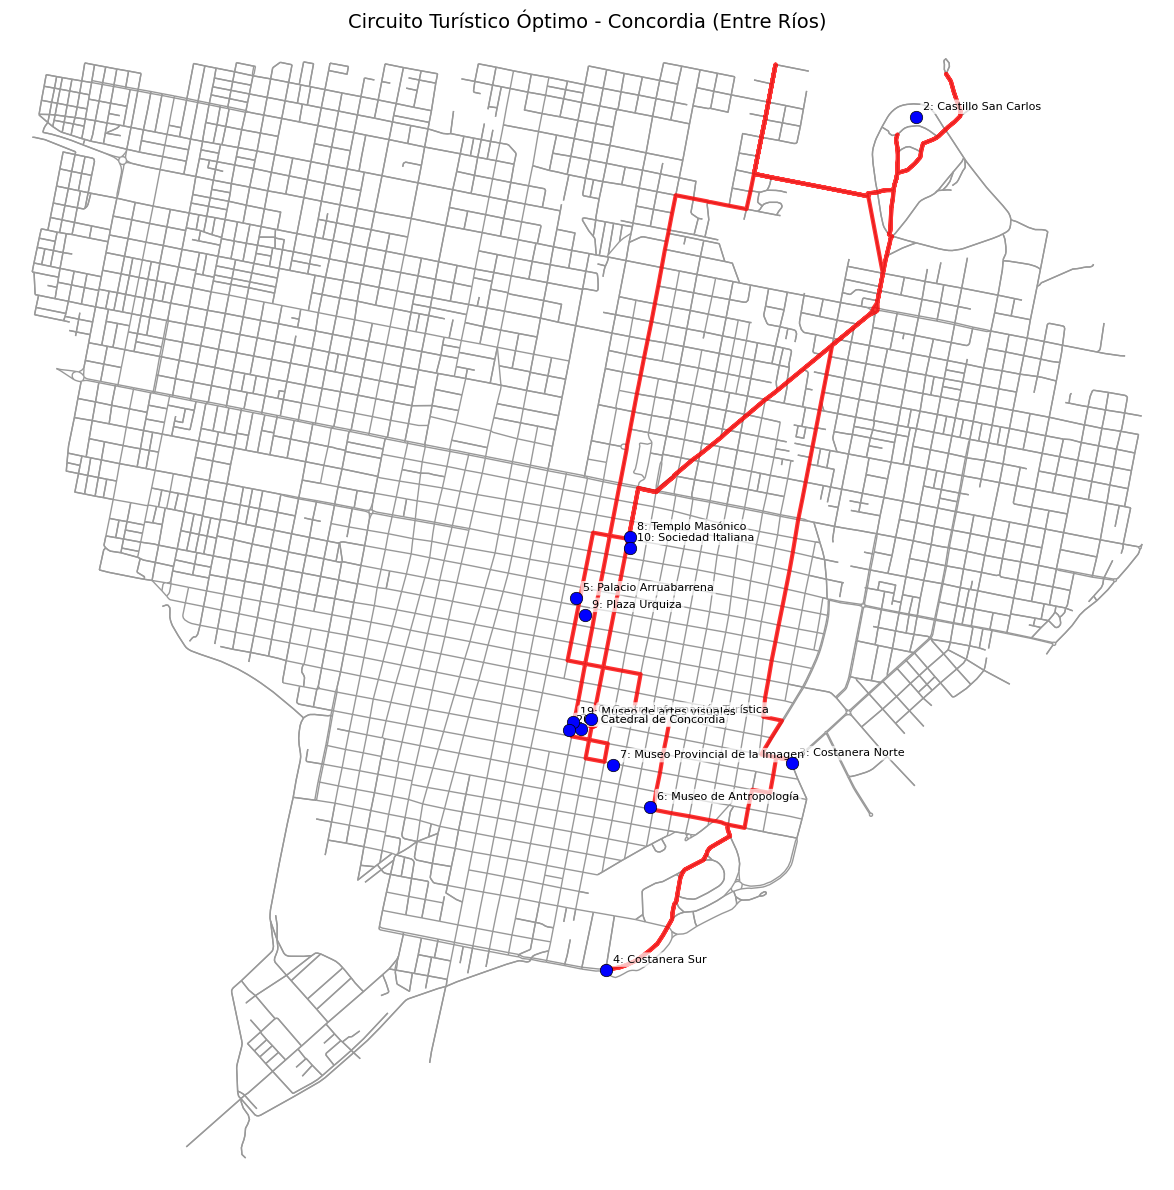


--- Resumen Final ---
Constructiva (Inserción): 426 min
Mejora local (2-opt):       417 min  (-2.2% vs inserción)
Metaheurística (Tabú):    410 min  (-3.7% vs inserción)


In [ ]:

import matplotlib.pyplot as plt

ruta_final = ruta_tabu if costo_tabu <= costo_2opt else ruta_2opt
print(f"Usando ruta de: {'Búsqueda Tabú' if costo_tabu <= costo_2opt else '2-opt'}")
print(f"Costo final: {min(costo_tabu, costo_2opt):.0f} minutos")

ruta_nodos = []
for k in range(len(ruta_final) - 1):
    tramo = ox.routing.shortest_path(
        G, nodos_origen[ruta_final[k]], nodos_origen[ruta_final[k + 1]],
        weight="travel_time"
    )
    if tramo is None:
        print(f"  ⚠ Sin camino entre paso {k} y {k+1}")
        continue
    if k > 0:
        tramo = tramo[1:]
    ruta_nodos.extend(tramo)

print(f"Ruta construida con {len(ruta_nodos)} nodos OSMnx")


fig, ax = ox.plot_graph_route(
    G, ruta_nodos,
    route_color="red",
    route_linewidth=3,
    route_alpha=0.8,
    node_size=0,
    bgcolor="white",
    figsize=(14, 12),
    show=False,
    close=False
)

# Marcar los puntos turísticos sobre el mapa
lats = [p["lat"] for p in puntos_turisticos2]
lons = [p["lon"] for p in puntos_turisticos2]
nombres = [p["nombre"] for p in puntos_turisticos2]
ax.scatter(lons, lats, c="blue", s=80, zorder=5, edgecolors="black", linewidths=0.5)
for i, (lon, lat, nom) in enumerate(zip(lons, lats, nombres)):
    ax.annotate(
        f"{i}: {nom}",
        (lon, lat),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.7)
    )

plt.title("Circuito Turístico Óptimo - Concordia (Entre Ríos)", fontsize=14)
plt.tight_layout()
plt.show()

print("\n--- Resumen Final ---")
print(f"Constructiva (Inserción): {costo_insercion:.0f} min")
print(f"Mejora local (2-opt):       {costo_2opt:.0f} min  ({-100*(costo_insercion-costo_2opt)/costo_insercion:+.1f}% vs inserción)")
print(f"Metaheurística (Tabú):    {min(costo_tabu, costo_2opt):.0f} min  ({-100*(costo_insercion-min(costo_tabu,costo_2opt))/costo_insercion:+.1f}% vs inserción)")


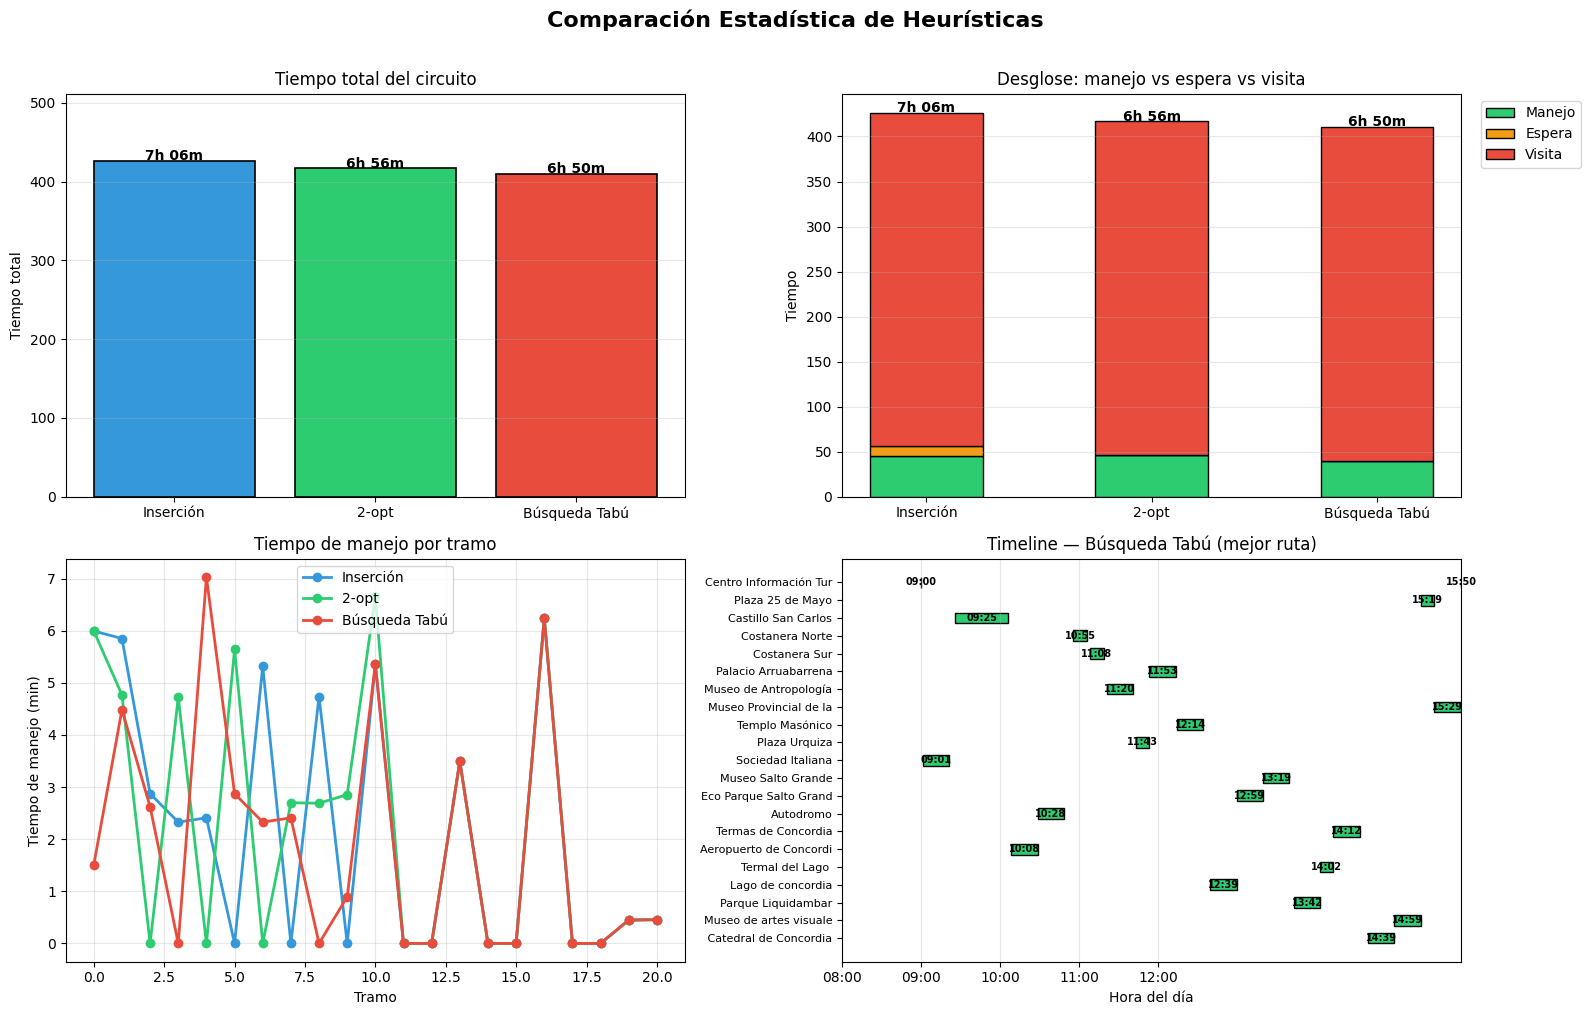

In [ ]:
#GRAFICOS COMPARATIVOS
def min_a_hhmm(m):
    h = int(m // 60)
    mm = int(m % 60)
    return f"{h}h {mm:02d}m"

#DESCOMPONER EN: MANEJO, ESPERA VISITA
def desglose_ruta(ruta, matriz_tiempos, puntos, hora_salida):
    tiempos_llegada, tiempos_salida, factible, _ = calcular_tiempos_ruta(
        ruta, matriz_tiempos, puntos, hora_salida
    )
    manejo_total = 0.0
    espera_total = 0.0
    visita_total = 0.0
    manejo_por_tramo = []
    etiquetas_tramos = []
    for idx in range(1, len(ruta)):
        i, j = ruta[idx-1], ruta[idx]
        t_viaje = matriz_tiempos[i][j]
        llegada_prevista = tiempos_salida[idx-1] + t_viaje
        apertura = hora_a_minutos(puntos[j]["apertura"])
        espera = max(0, apertura - llegada_prevista)
        visita = puntos[j]["visit_time"]
        manejo_total += t_viaje
        espera_total += espera
        visita_total += visita
        manejo_por_tramo.append(t_viaje)
        etiquetas_tramos.append(f"{puntos[i]['nombre'][:12]}\n→{puntos[j]['nombre'][:12]}")
    return manejo_total, espera_total, visita_total, manejo_por_tramo, etiquetas_tramos

#OBTENER DATOS HEURISTICAS
rutas = {
    "Inserción": ruta_insercion,
    "2-opt": ruta_2opt,
    "Búsqueda Tabú": ruta_tabu,
}
costos = {
    "Inserción": costo_insercion,
    "2-opt": costo_2opt,
    "Búsqueda Tabú": costo_tabu,
}

stats = {}
for nombre, ruta in rutas.items():
    m, e, v, tramos, etiq = desglose_ruta(ruta, matriz_tiempos, puntos_turisticos2, HORA_SALIDA)
    stats[nombre] = {"manejo": m, "espera": e, "visita": v, "tramos": tramos, "etiquetas": etiq}

df = pd.DataFrame(stats).T
df["total"] = df["manejo"] + df["espera"] + df["visita"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Comparación Estadística de Heurísticas", fontsize=16, fontweight="bold", y=1.01)

#GRAFICO A
ax = axes[0, 0]
colores = ["#3498db", "#2ecc71", "#e74c3c"]
barras = ax.bar(stats.keys(), df["total"].values, color=colores, edgecolor="black", linewidth=1.2)
for barra, val in zip(barras, df["total"].values):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 1,
            min_a_hhmm(val), ha="center", fontweight="bold")
ax.set_ylabel("Tiempo total")
ax.set_title("Tiempo total del circuito")
ax.set_ylim(0, df["total"].max() * 1.2)
ax.grid(axis="y", alpha=0.3)

#GRAFICO B
ax = axes[0, 1]
x = np.arange(len(stats))
w = 0.5
b1 = ax.bar(x, df["manejo"].values, w, label="Manejo", color="#2ecc71", edgecolor="black")
b2 = ax.bar(x, df["espera"].values, w, bottom=df["manejo"].values,
            label="Espera", color="#f39c12", edgecolor="black")
b3 = ax.bar(x, df["visita"].values, w,
            bottom=df["manejo"].values + df["espera"].values,
            label="Visita", color="#e74c3c", edgecolor="black")
for i in range(len(stats)):
    ax.text(i, df["total"].values[i] + 1, min_a_hhmm(df['total'].values[i]),
            ha="center", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(stats.keys())
ax.set_ylabel("Tiempo")
ax.set_title("Desglose: manejo vs espera vs visita")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)

#GRAFICO C
ax = axes[1, 0]
for i, (nombre, s) in enumerate(stats.items()):
    ax.plot(range(len(s["tramos"])), s["tramos"],
            marker="o", label=nombre, color=colores[i], linewidth=2, markersize=6)
ax.set_xlabel("Tramo")
ax.set_ylabel("Tiempo de manejo (min)")
ax.set_title("Tiempo de manejo por tramo")
ax.legend()
ax.grid(alpha=0.3)

#GRAFICO D
ax = axes[1, 1]
mejor_nombre = min(stats, key=lambda k: df.loc[k, "total"])
mejor_ruta = rutas[mejor_nombre]
tl, ts, _, _ = calcular_tiempos_ruta(mejor_ruta, matriz_tiempos, puntos_turisticos2, HORA_SALIDA)

for idx in range(len(mejor_ruta)):
    pid = mejor_ruta[idx]
    ini = tl[idx]
    dur = ts[idx] - tl[idx]
    color = "#2ecc71" if dur > 0 else "#3498db"
    ax.barh(pid, dur, left=ini, height=0.6, color=color, edgecolor="black")
    ax.text(ini + dur/2, pid, f"{minutos_a_hora(ini)}",
            ha="center", va="center", fontsize=7, fontweight="bold")

nombres_cortos = [p["nombre"][:22] for p in puntos_turisticos2]
ax.set_yticks(range(len(puntos_turisticos2)))
ax.set_yticklabels(nombres_cortos, fontsize=8)
ax.set_xlabel("Hora del día")
ax.set_title(f"Timeline — {mejor_nombre} (mejor ruta)")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)

# Horas en el eje X
horas = range(8, 13)
ax.set_xticks([h*60 for h in horas])
ax.set_xticklabels([f"{h:02d}:00" for h in horas])

plt.tight_layout()
plt.show()



=== GENERANDO GRAFO COMPLETO CON NODOS SEPARADOS ===

Nodos: 11
Aristas: 110


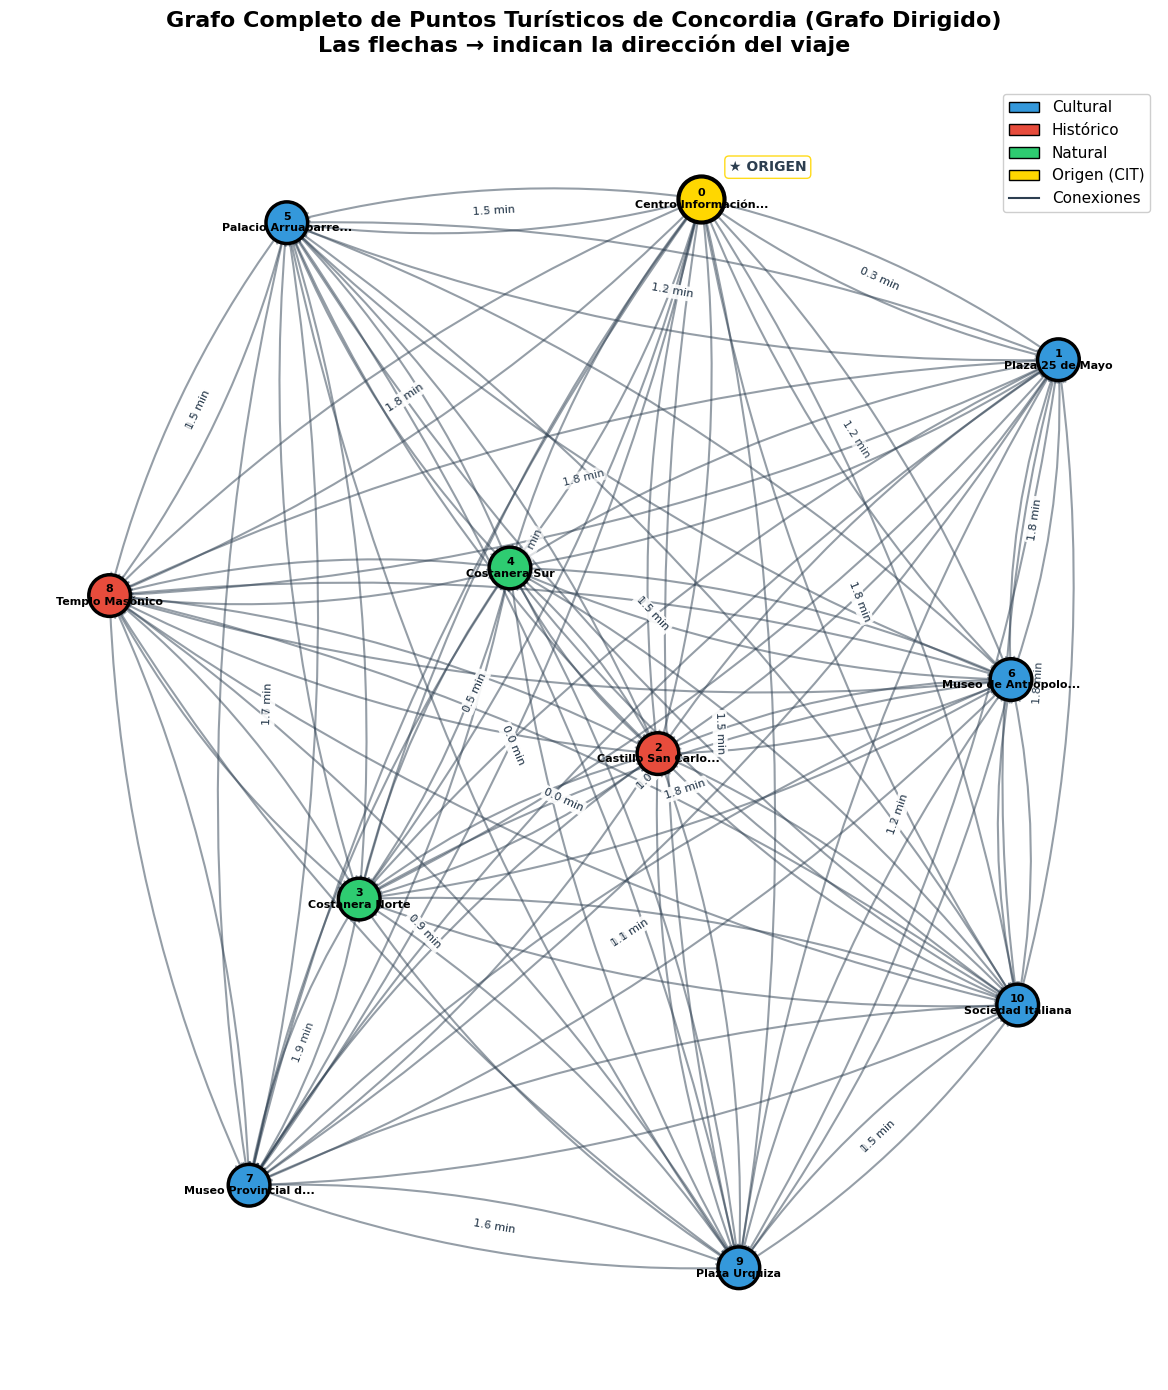

In [ ]:
# ============================================
# GRAFO DE PUNTOS TURÍSTICOS - TODAS LAS CONEXIONES
# CON NODOS SEPARADOS (LAYOUT)
# ============================================
print("\n=== GENERANDO GRAFO COMPLETO CON NODOS SEPARADOS ===\n")

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# ============================================
# 1. CREAR EL GRAFO DIRIGIDO
# ============================================
# Usar los 11 puntos principales
puntos_a_usar = puntos_turisticos2[:11]

G_completo = nx.DiGraph()

for p in puntos_a_usar:
    G_completo.add_node(
        p['id'],
        nombre=p['nombre'],
        tipo=p['tipo'],
        lat=p['lat'],
        lon=p['lon']
    )

# Agregar TODAS las conexiones (con tiempo < 10 min para no saturar)
# Si quieres TODAS las conexiones, usa < 999
for i in range(len(puntos_a_usar)):
    for j in range(len(puntos_a_usar)):
        if i != j:
            tiempo = matriz_tiempos[i][j]
            if tiempo < 10:  # Ajusta este valor para más o menos conexiones
                G_completo.add_edge(i, j, weight=round(tiempo, 1))

print(f"Nodos: {G_completo.number_of_nodes()}")
print(f"Aristas: {G_completo.number_of_edges()}")

# ============================================
# 2. CONFIGURAR POSICIONES CON LAYOUT
# ============================================
# Spring layout para separar nodos automáticamente
pos = nx.spring_layout(
    G_completo,
    seed=42,        # Fija la semilla para reproducibilidad
    k=2.5,          # Distancia entre nodos (más grande = más separados)
    iterations=100,
    scale=3.0
)

# Alternativa: si quieres mantener la forma geográfica aproximada
# (descomentar para usar coordenadas reales)
# pos = {}
# for p in puntos_a_usar:
#     x = (p['lon'] - (-58.020)) * 80
#     y = (p['lat'] - (-31.410)) * 80
#     pos[p['id']] = (x, y)

# ============================================
# 3. CONFIGURAR COLORES POR TIPO
# ============================================
colores_tipo = {
    'Cultural': '#3498db',   # Azul
    'Histórico': '#e74c3c',  # Rojo
    'Natural': '#2ecc71'     # Verde
}

node_colors = [colores_tipo.get(p['tipo'], '#95a5a6') for p in puntos_a_usar]

# ============================================
# 4. DIBUJAR EL GRAFO
# ============================================
fig, ax = plt.subplots(figsize=(18, 14))

# --- NODOS ---
nx.draw_networkx_nodes(
    G_completo, pos,
    node_size=900,
    node_color=node_colors,
    edgecolors='black',
    linewidths=2.5,
    ax=ax
)

# --- ETIQUETAS DE NODOS (con nombres) ---
labels = {}
for p in puntos_a_usar:
    nombre_corto = p['nombre']
    if len(nombre_corto) > 18:
        nombre_corto = nombre_corto[:18] + '...'
    labels[p['id']] = f"{p['id']}\n{nombre_corto}"

nx.draw_networkx_labels(
    G_completo, pos,
    labels=labels,
    font_size=8,
    font_weight='bold',
    ax=ax
)

# --- ARISTAS (todas las conexiones) ---
nx.draw_networkx_edges(
    G_completo, pos,
    edge_color='#2c3e50',
    width=1.5,
    alpha=0.5,
    arrows=True,
    arrowstyle='->',
    arrowsize=15,
    connectionstyle='arc3,rad=0.1',
    ax=ax
)

# --- ETIQUETAS DE PESOS (solo algunas para no saturar) ---
# Mostrar solo los pesos más pequeños (< 2 min) para no saturar
edge_labels = {}
for u, v, data in G_completo.edges(data=True):
    if data['weight'] < 2:  # Solo mostrar conexiones muy cercanas
        edge_labels[(u, v)] = f"{data['weight']} min"

nx.draw_networkx_edge_labels(
    G_completo, pos,
    edge_labels=edge_labels,
    font_size=8,
    font_color='#2c3e50',
    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.7),
    ax=ax
)

# --- ORIGEN (DESTACADO) ---
origen = puntos_a_usar[0]
nx.draw_networkx_nodes(
    G_completo, pos,
    nodelist=[origen['id']],
    node_size=1100,
    node_color='gold',
    edgecolors='black',
    linewidths=3,
    ax=ax
)

# Etiqueta "★ ORIGEN"
ax.annotate(
    '★ ORIGEN',
    xy=pos[origen['id']],
    xytext=(20, 20),
    textcoords='offset points',
    fontsize=10,
    fontweight='bold',
    color='#2c3e50',
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gold", alpha=0.9)
)

# ============================================
# 5. LEYENDA
# ============================================
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor='#3498db', edgecolor='black', label='Cultural'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='Histórico'),
    Patch(facecolor='#2ecc71', edgecolor='black', label='Natural'),
    Patch(facecolor='gold', edgecolor='black', label='Origen (CIT)'),
    Line2D([0], [0], color='#2c3e50', linewidth=1.5, label='Conexiones')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11, framealpha=0.95)

# ============================================
# 6. TÍTULO Y CONFIGURACIÓN
# ============================================
ax.set_title(
    'Grafo Completo de Puntos Turísticos de Concordia (Grafo Dirigido)\n'
    'Las flechas → indican la dirección del viaje',
    fontsize=16,
    fontweight='bold',
    pad=25
)

ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.show()


=== GENERANDO GRAFO CON CONEXIONES RELEVANTES ===

Nodos: 11
Aristas: 94


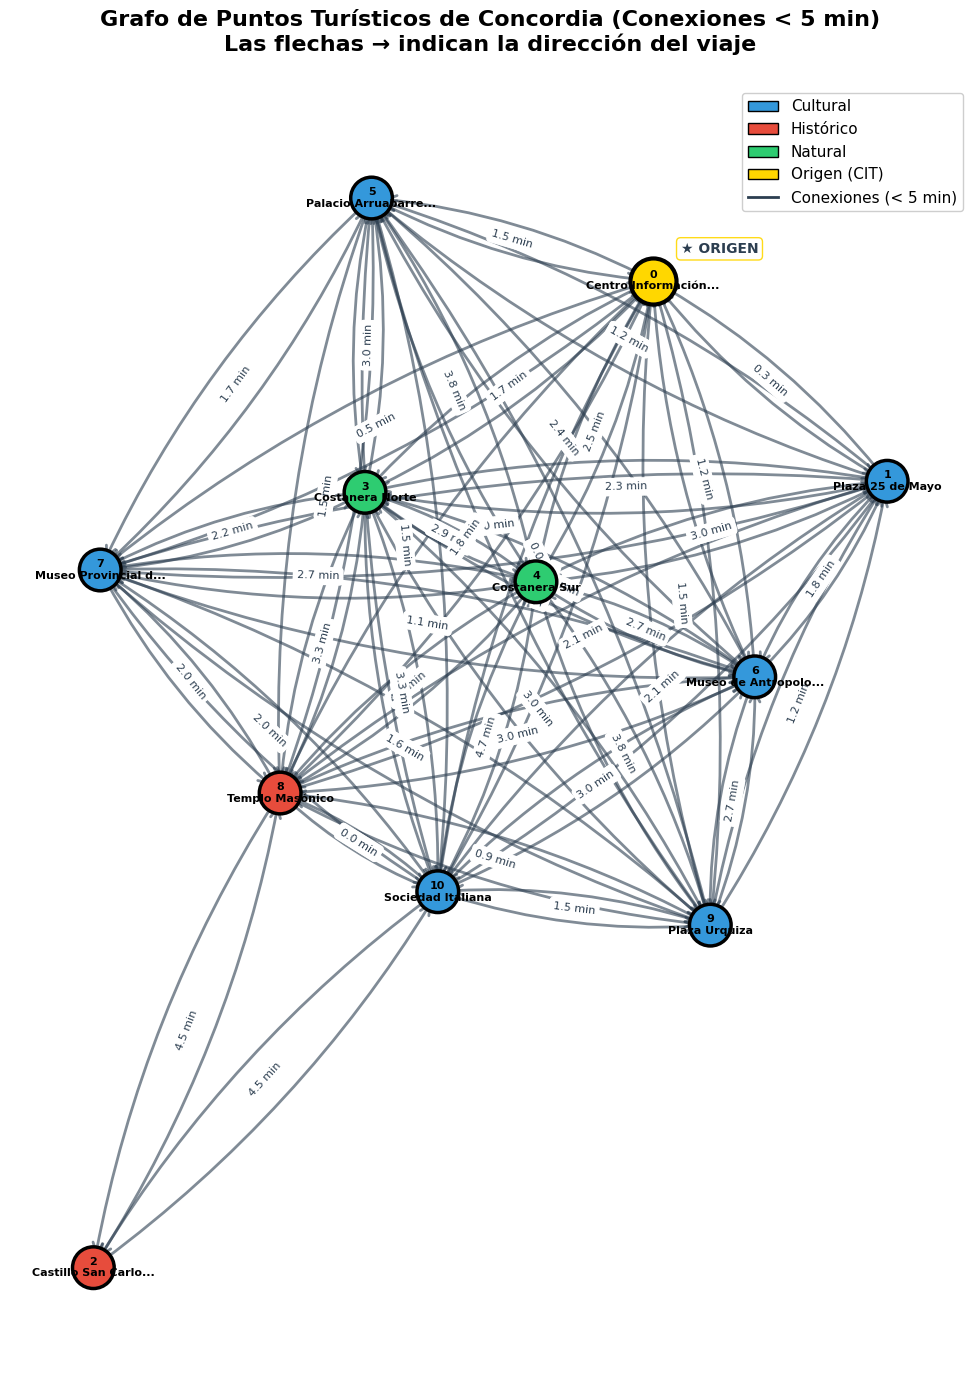

In [ ]:
# ============================================
# GRAFO CON SOLO CONEXIONES RELEVANTES (< 5 min)
# ============================================
print("\n=== GENERANDO GRAFO CON CONEXIONES RELEVANTES ===\n")

# Crear grafo solo con conexiones < 5 minutos
G_filtrado = nx.DiGraph()

for p in puntos_a_usar:
    G_filtrado.add_node(
        p['id'],
        nombre=p['nombre'],
        tipo=p['tipo']
    )

# Solo conexiones con tiempo < 5 minutos
for i in range(len(puntos_a_usar)):
    for j in range(len(puntos_a_usar)):
        if i != j:
            tiempo = matriz_tiempos[i][j]
            if tiempo < 5:
                G_filtrado.add_edge(i, j, weight=round(tiempo, 1))

print(f"Nodos: {G_filtrado.number_of_nodes()}")
print(f"Aristas: {G_filtrado.number_of_edges()}")

# ============================================
# DIBUJAR CON EL MISMO CÓDIGO DE ARRIBA
# ============================================
fig, ax = plt.subplots(figsize=(18, 14))

# Posiciones
pos = nx.spring_layout(G_filtrado, seed=42, k=2.5, iterations=100, scale=3.0)

# Nodos
node_colors = [colores_tipo.get(p['tipo'], '#95a5a6') for p in puntos_a_usar]
nx.draw_networkx_nodes(G_filtrado, pos, node_size=900, node_color=node_colors,
                       edgecolors='black', linewidths=2.5, ax=ax)

# Etiquetas
labels = {}
for p in puntos_a_usar:
    nombre_corto = p['nombre'][:18] + '...' if len(p['nombre']) > 18 else p['nombre']
    labels[p['id']] = f"{p['id']}\n{nombre_corto}"
nx.draw_networkx_labels(G_filtrado, pos, labels=labels, font_size=8, font_weight='bold', ax=ax)

# Aristas
nx.draw_networkx_edges(G_filtrado, pos, edge_color='#2c3e50', width=2, alpha=0.6,
                       arrows=True, arrowstyle='->', arrowsize=18,
                       connectionstyle='arc3,rad=0.1', ax=ax)

# Pesos (mostrar todos)
edge_labels = {(u, v): f"{d['weight']} min" for u, v, d in G_filtrado.edges(data=True)}
nx.draw_networkx_edge_labels(G_filtrado, pos, edge_labels=edge_labels,
                             font_size=8, font_color='#2c3e50', ax=ax)

# Origen
nx.draw_networkx_nodes(G_filtrado, pos, nodelist=[0], node_size=1100,
                       node_color='gold', edgecolors='black', linewidths=3, ax=ax)
ax.annotate('★ ORIGEN', xy=pos[0], xytext=(20, 20), textcoords='offset points',
            fontsize=10, fontweight='bold', color='#2c3e50',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gold", alpha=0.9))

# Leyenda
legend_elements = [
    Patch(facecolor='#3498db', edgecolor='black', label='Cultural'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='Histórico'),
    Patch(facecolor='#2ecc71', edgecolor='black', label='Natural'),
    Patch(facecolor='gold', edgecolor='black', label='Origen (CIT)'),
    Line2D([0], [0], color='#2c3e50', linewidth=2, label='Conexiones (< 5 min)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11, framealpha=0.95)

ax.set_title('Grafo de Puntos Turísticos de Concordia (Conexiones < 5 min)\nLas flechas → indican la dirección del viaje',
             fontsize=16, fontweight='bold', pad=25)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.show()


=== GENERANDO GRAFO CON NODOS SEPARADOS ===

Ruta óptima (filtrada): [0, 10, 2, 3, 4, 6, 9, 5, 8, 1, 7, 0]


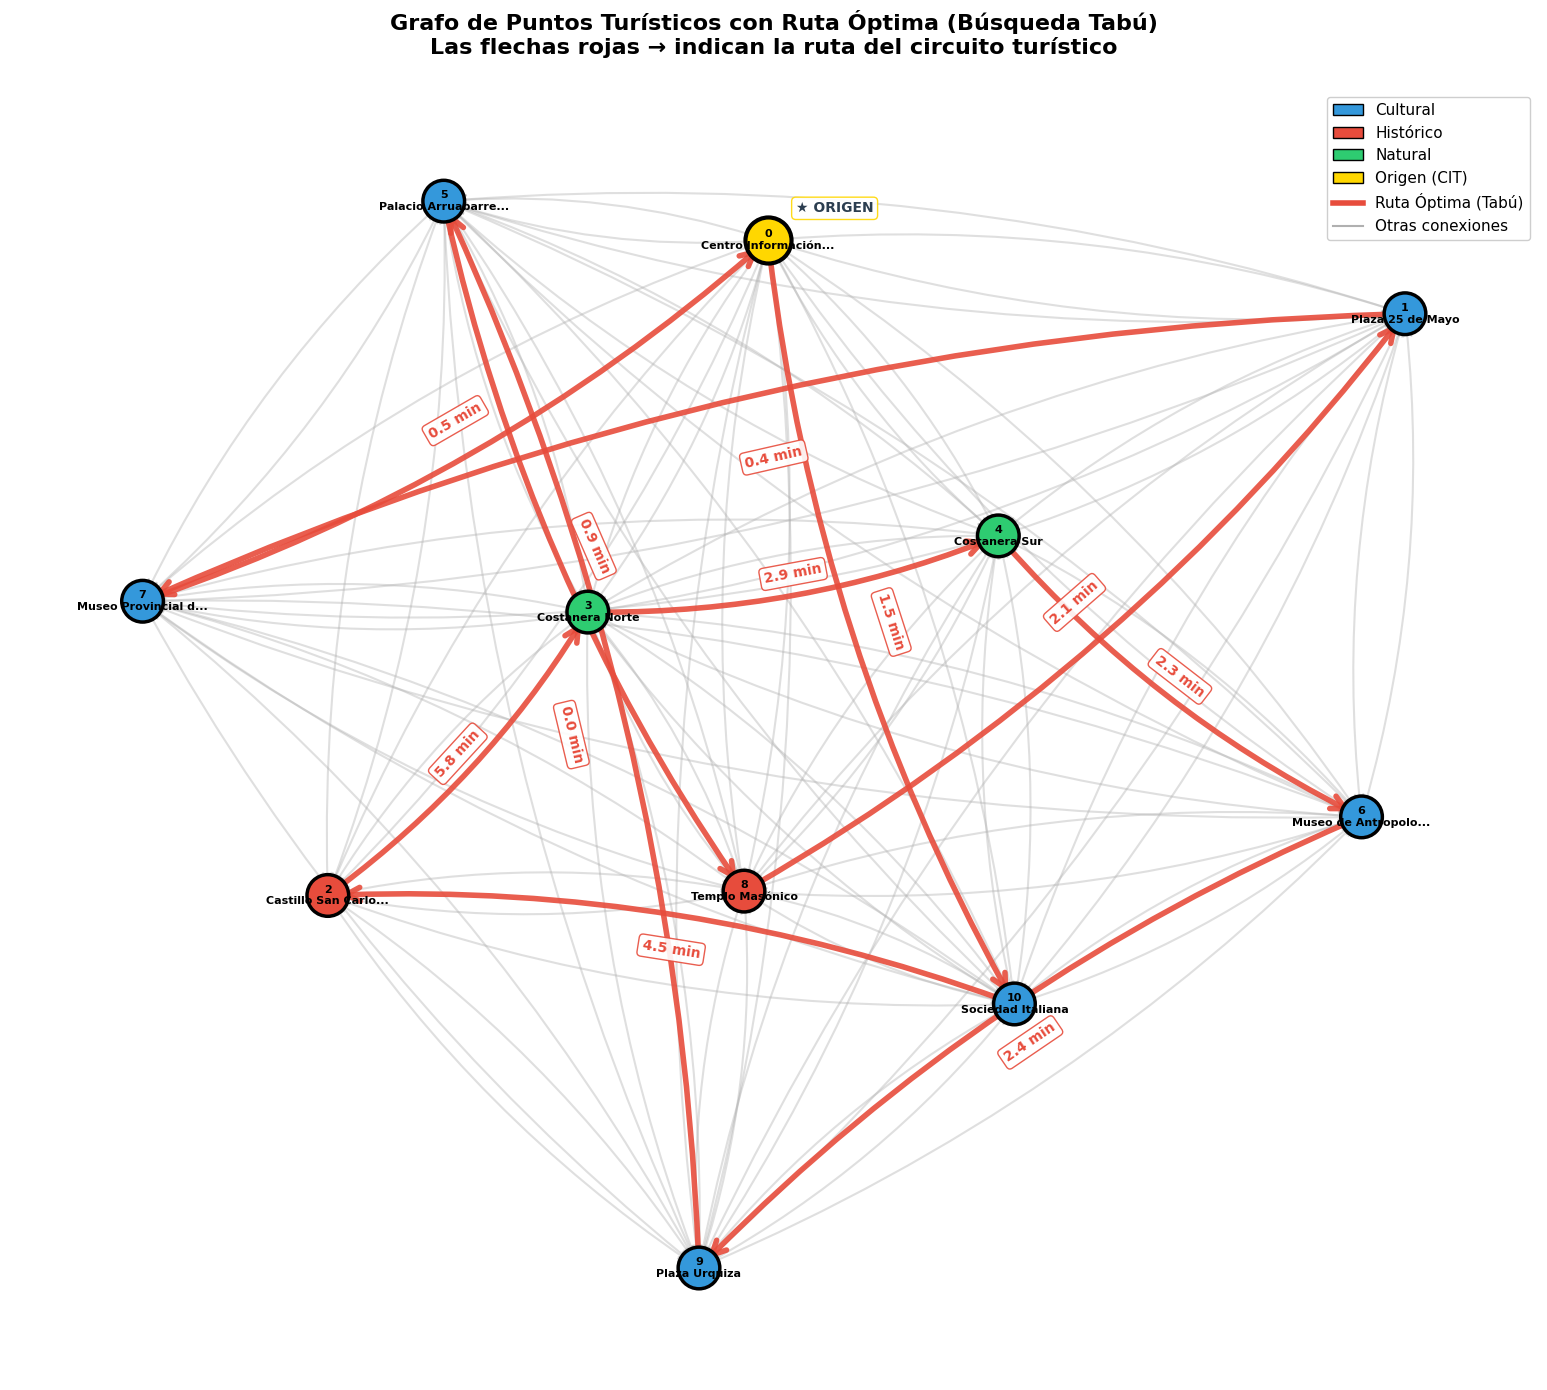

In [ ]:
# ============================================
# GRAFO CON RUTA ÓPTIMA - VERSIÓN SEPARADA
# ============================================
print("\n=== GENERANDO GRAFO CON NODOS SEPARADOS ===\n")

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# ============================================
# 1. CREAR EL GRAFO CON TODAS LAS CONEXIONES
# ============================================
# Usar todos los puntos (21) o solo los principales (11)
# Recomiendo usar los 11 principales para mejor visualización
puntos_a_usar = puntos_turisticos2[:11]  # Solo los 11 primeros

G_ruta = nx.DiGraph()

for p in puntos_a_usar:
    G_ruta.add_node(
        p['id'],
        nombre=p['nombre'],
        tipo=p['tipo'],
        lat=p['lat'],
        lon=p['lon']
    )

# Agregar conexiones con tiempo < 6 min (un poco más permisivo)
for i in range(len(puntos_a_usar)):
    for j in range(len(puntos_a_usar)):
        if i != j and matriz_tiempos[i][j] < 6:
            G_ruta.add_edge(i, j, weight=round(matriz_tiempos[i][j], 1))

# ============================================
# 2. IDENTIFICAR LA RUTA ÓPTIMA (TABÚ)
# ============================================
mejor_ruta = ruta_tabu  # La ruta de la Búsqueda Tabú

# Filtrar la ruta para que solo incluya nodos que están en el grafo
ruta_filtrada = []
for nodo in mejor_ruta:
    if nodo < len(puntos_a_usar):  # Solo si el nodo está en el grafo
        ruta_filtrada.append(nodo)

print(f"Ruta óptima (filtrada): {ruta_filtrada}")

# Identificar aristas de la ruta
aristas_ruta = []
for k in range(len(ruta_filtrada) - 1):
    i = ruta_filtrada[k]
    j = ruta_filtrada[k + 1]
    if G_ruta.has_edge(i, j):
        aristas_ruta.append((i, j))

# ============================================
# 3. CALCULAR POSICIONES CON LAYOUT
# ============================================
# Usar spring_layout para separar los nodos automáticamente
# Ajustar parámetros para más separación
pos = nx.spring_layout(
    G_ruta,
    seed=42,  # Fija la semilla para que siempre sea el mismo
    k=2.5,    # Distancia entre nodos (más grande = más separados)
    iterations=100,
    scale=3.0  # Escala general del gráfico
)

# Alternativa: usar posiciones geográficas pero escaladas
# (descomentar si quieres mantener la forma geográfica)
# pos = {}
# for p in puntos_a_usar:
#     x = (p['lon'] - (-58.020)) * 80
#     y = (p['lat'] - (-31.410)) * 80
#     pos[p['id']] = (x, y)

# ============================================
# 4. CONFIGURAR COLORES
# ============================================
colores_tipo = {
    'Cultural': '#3498db',
    'Histórico': '#e74c3c',
    'Natural': '#2ecc71'
}

node_colors = [colores_tipo.get(p['tipo'], '#95a5a6') for p in puntos_a_usar]

# ============================================
# 5. DIBUJAR EL GRAFO
# ============================================
fig, ax = plt.subplots(figsize=(18, 14))

# --- NODOS ---
nx.draw_networkx_nodes(
    G_ruta, pos,
    node_size=900,
    node_color=node_colors,
    edgecolors='black',
    linewidths=2.5,
    ax=ax
)

# --- ETIQUETAS DE NODOS ---
labels = {}
for p in puntos_a_usar:
    nombre_corto = p['nombre']
    if len(nombre_corto) > 18:
        nombre_corto = nombre_corto[:18] + '...'
    labels[p['id']] = f"{p['id']}\n{nombre_corto}"

nx.draw_networkx_labels(
    G_ruta, pos,
    labels=labels,
    font_size=8,
    font_weight='bold',
    ax=ax
)

# --- ARISTAS NO RUTA (GRISES) ---
aristas_no_ruta = [(u, v) for u, v in G_ruta.edges() if (u, v) not in aristas_ruta]
if aristas_no_ruta:
    nx.draw_networkx_edges(
        G_ruta, pos,
        edgelist=aristas_no_ruta,
        edge_color='#b0b0b0',
        width=1.5,
        alpha=0.4,
        arrows=True,
        arrowstyle='->',
        arrowsize=15,
        connectionstyle='arc3,rad=0.1',
        ax=ax
    )

# --- ARISTAS RUTA (ROJAS) ---
if aristas_ruta:
    nx.draw_networkx_edges(
        G_ruta, pos,
        edgelist=aristas_ruta,
        edge_color='#e74c3c',
        width=4,
        alpha=0.9,
        arrows=True,
        arrowstyle='->',
        arrowsize=25,
        connectionstyle='arc3,rad=0.1',
        ax=ax
    )

# --- ETIQUETAS DE PESOS (SOLO RUTA) ---
edge_labels = {}
for u, v in aristas_ruta:
    if G_ruta.has_edge(u, v):
        edge_labels[(u, v)] = f"{G_ruta.edges[u, v]['weight']} min"

if edge_labels:
    nx.draw_networkx_edge_labels(
        G_ruta, pos,
        edge_labels=edge_labels,
        font_size=10,
        font_color='#e74c3c',
        font_weight='bold',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#e74c3c", alpha=0.9),
        ax=ax
    )

# --- ORIGEN (DESTACADO) ---
origen = puntos_a_usar[0]
nx.draw_networkx_nodes(
    G_ruta, pos,
    nodelist=[origen['id']],
    node_size=1100,
    node_color='gold',
    edgecolors='black',
    linewidths=3,
    ax=ax
)

# Agregar texto "★ ORIGEN" cerca del nodo origen
ax.annotate(
    '★ ORIGEN',
    xy=pos[origen['id']],
    xytext=(20, 20),
    textcoords='offset points',
    fontsize=10,
    fontweight='bold',
    color='#2c3e50',
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gold", alpha=0.9)
)

# ============================================
# 6. LEYENDA
# ============================================
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor='#3498db', edgecolor='black', label='Cultural'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='Histórico'),
    Patch(facecolor='#2ecc71', edgecolor='black', label='Natural'),
    Patch(facecolor='gold', edgecolor='black', label='Origen (CIT)'),
    Line2D([0], [0], color='#e74c3c', linewidth=4, label='Ruta Óptima (Tabú)'),
    Line2D([0], [0], color='#b0b0b0', linewidth=1.5, label='Otras conexiones')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11, framealpha=0.95)

# ============================================
# 7. TÍTULO Y CONFIGURACIÓN
# ============================================
ax.set_title(
    'Grafo de Puntos Turísticos con Ruta Óptima (Búsqueda Tabú)\n'
    'Las flechas rojas → indican la ruta del circuito turístico',
    fontsize=16,
    fontweight='bold',
    pad=25
)

ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.show()